In [2]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegFileWriter, FuncAnimation

In [3]:
def Get_Edge_Distance(v0,v1,P):
    e = v1 - v0
    w = P - v0
    t0 = torch.sum(e*w, dim=-1) 
    t1 = torch.sum(e*e, dim=-1)
    t = t0/t1
    #print(t.shape)
    t_clamp = torch.clamp(t, 0.0, 1.0) # |w| cos(theta) 가 |e| 보다 길면 1, 0보다 작으면 0, 중간이면 |w| cos(theta) / |e| 
    q = v0  + (e * t_clamp[...,None])

    return torch.sum((P-q) * (P-q), dim=-1)

def Get_NDC_Points(H, W, device):
    x = torch.arange(W, device=device)
    y = torch.arange(H, device=device)
    Y,X = torch.meshgrid([y,x], indexing="ij")
    Y = torch.flip(Y,dims=[0])

    NDCX = (2.0*(X+0.5)) / W - 1.0
    NDCY = (2.0*(Y+0.5)) / H - 1.0

    P =  torch.stack([NDCX,NDCY], dim=-1)

    return P

def edge(v0,v1,P):
    return ((P[...,0] - v0[...,0]) *  (v1[...,1] - v0[...,1])) - ((P[...,1] - v0[...,1]) *  (v1[...,0] - v0[...,0]))

def Render_Soft_Edge(vertices,colors, k, H, W):
    P = Get_NDC_Points(H,W, vertices.device)

    v0, v1, v2 = vertices[0], vertices[1],vertices[2]

    area = edge(v0, v1, v2)
    s = 1.0 if area >=0.0 else -1.0
    area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
    w2 = edge(v0, v1, P) / area
    w0 = edge(v1, v2, P) / area
    w1 = edge(v2, v0, P) / area
    inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

    d0 = Get_Edge_Distance(v0,v1,P)
    d1 = Get_Edge_Distance(v1,v2,P)
    d2 = Get_Edge_Distance(v2,v0,P)

    d = torch.stack([d0,d1,d2], dim=0).min(dim=0).values
    g = torch.exp(-k*d)

    img = torch.zeros((H, W, 3), device=vertices.device, dtype=vertices.dtype)

    rgbs = (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    rgbs = torch.clamp(rgbs, 0.0 , 1.0)
    
    gaussian_rgbs = g[...,None] * (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    gaussian_rgbs = torch.clamp(gaussian_rgbs, 0.0 , 1.0)
    
    img[...] = gaussian_rgbs[...]
    img[inside] = rgbs[inside]

    return img

def Render_Hard_Edge(vertices, colors, H, W):
    P = Get_NDC_Points(H,W, vertices.device)

    v0, v1, v2 = vertices[0], vertices[1],vertices[2]

    area = edge(v0, v1, v2)
    s = 1.0 if area >=0.0 else -1.0
    area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
    w2 = edge(v0, v1, P) / area
    w0 = edge(v1, v2, P) / area
    w1 = edge(v2, v0, P) / area
    inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

    img = torch.zeros((H, W, 3), device=vertices.device, dtype=torch.float32)
    rgbs = (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    rgbs = torch.clamp(rgbs, 0.0 , 1.0)
    img[inside] = rgbs[inside]

    return img


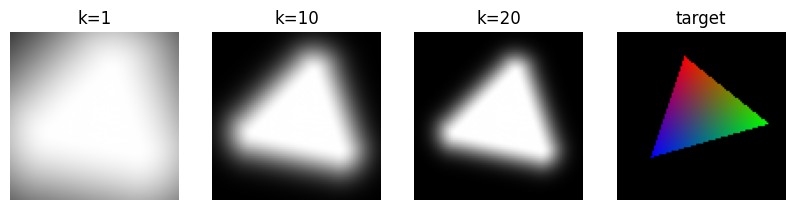

In [4]:
H = 96
W = 96
device = 'cuda'

init_vertices = torch.tensor([[0.2, 0.5], 
                         [0.5, -0.4],
                         [-0.5,-0.2]],
                         dtype=torch.float32, device=device)
init_colors = torch.tensor([[1.0,1.0,1.0],
                       [1.0,1.0,1.0],
                       [1.0,1.0,1.0]],
                        dtype=torch.float32, device=device)

vertices = torch.tensor([[-0.2, 0.7], 
                         [0.8, -0.1],
                         [-0.6,-0.5]],
                         dtype=torch.float32, device=device)
colors = torch.tensor([[1.0,0.0,0.0],
                       [0.0,1.0,0.0],
                       [0.0,0.0,1.0]],
                        dtype=torch.float32, device=device)

image = Render_Soft_Edge(init_vertices,init_colors, 1, H,W)
image1 = Render_Soft_Edge(init_vertices,init_colors, 10, H,W)
image2 = Render_Soft_Edge(init_vertices,init_colors, 20, H,W)
target_image = Render_Hard_Edge(vertices, colors, H, W)

fig, ax = plt.subplots(1,4, figsize=(10,3))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')

ax[0].set_title('k=1')
ax[1].set_title('k=10')
ax[2].set_title('k=20')
ax[3].set_title('target')
im0 = ax[0].imshow(image.cpu().detach().numpy())
im1 = ax[1].imshow(image1.cpu().detach().numpy())
im2 = ax[2].imshow(image2.cpu().detach().numpy())
im2 = ax[3].imshow(target_image.cpu().detach().numpy())

plt.show()

In [17]:
train_time = 300
v = init_vertices.clone().requires_grad_(True)
c = init_colors.clone().requires_grad_(True)
optimizer = torch.optim.Adam([v, c], lr=0.01)

frames = []
filename = 'Soft_Edge.mp4'
title = "Soft Edge Training"
fps = 30
init_k = 10

for step in range(train_time):
    optimizer.zero_grad()
    k = init_k * (step + 1)
    current_image = Render_Soft_Edge(v, c, k,H,W)
    loss = torch.mean((target_image - current_image)**2)

    loss.backward()
    optimizer.step()

    frames.append(current_image.cpu().detach().numpy())
    
fig, ax = plt.subplots(figsize=(6,6))
ax.set_title(title)
ax.axis('off')
image = ax.imshow(frames[0], vmin=0.0, vmax=1.0, interpolation='nearest')
text = ax.text(0.5, -0.05, f"Iteration : 0", ha='center', fontsize = 12, transform=ax.transAxes)

def update_animation(frame_index):
    image.set_array(frames[frame_index])
    text.set_text(f"Iteration : {frame_index}")
    return [image, text]

writer = FFMpegFileWriter(fps=fps,bitrate=180)
anim = FuncAnimation(fig, update_animation,frames=len(frames), interval=1000/fps , blit=True)

anim.save(filename=filename, fps=fps)
plt.close(fig)


(96, 96, 1)


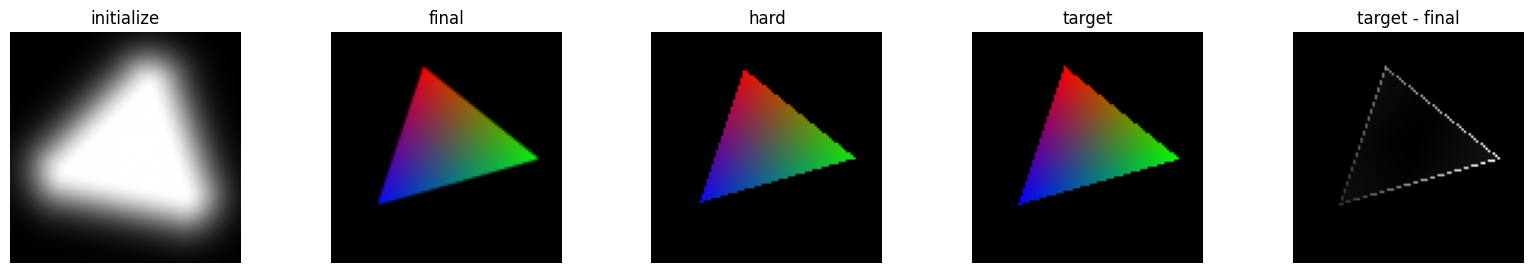

In [20]:
ret_fig, final_ret_ax = plt.subplots(1,5, figsize=(20,3))
final_ret_ax[0].axis('off')
final_ret_ax[1].axis('off')
final_ret_ax[2].axis('off')
final_ret_ax[3].axis('off')
final_ret_ax[4].axis('off')

final_ret_ax[0].set_title('initialize')
final_ret_ax[1].set_title('final')
final_ret_ax[2].set_title('hard')
final_ret_ax[3].set_title('target')
final_ret_ax[4].set_title('target - final')

final_hard_image = Render_Hard_Edge(v, c,H,W).cpu().detach().numpy()
target = target_image.cpu().detach().numpy()
t_f = abs(target - final_hard_image)
gray =  0.299 * t_f[..., 0] + 0.587 * t_f[..., 1] + 0.114 * t_f[..., 2]
gray = gray[...,None]

print(gray.shape)
im_0 = final_ret_ax[0].imshow(frames[0])
im_1 = final_ret_ax[1].imshow(frames[-1])
im_1 = final_ret_ax[2].imshow(final_hard_image)
im_2 = final_ret_ax[3].imshow(target)
im_3 = final_ret_ax[4].imshow(gray, cmap='gray')

plt.show()

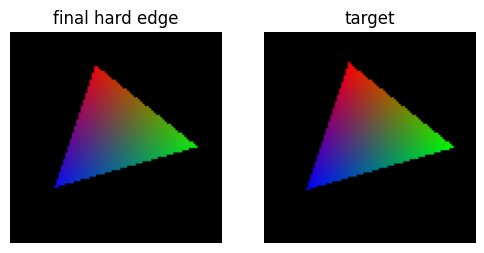

In [19]:
final_hard_image = Render_Hard_Edge(v, c,H,W)

fig_ , ret_ax = plt.subplots(1,2,figsize=(6,3))
ret_ax[0].axis('off')
ret_ax[1].axis('off')
ret_ax[0].set_title('final hard edge')
ret_ax[1].set_title('target')
im_0 = ret_ax[0].imshow(final_hard_image.cpu().detach().numpy())
im_2 = ret_ax[1].imshow(target)
plt.show()